# Multi-Label SVM and K-Means Clustering

Assigns family, genus and species to recorded frog calls from 22 MFCC coefficients, treating the three taxonomic levels as three labels on one instance. A Gaussian-kernel SVM gets all three right on 98.75% of test calls. K-means on the same features, labelled after the fact by cluster majority, reaches a Hamming score of 0.7776.

**Data:** Anuran Calls (MFCCs); 7,195 syllables, 22 features, 4 families, 8 genera, 10 species; UCI Machine Learning Repository
https://archive.ics.uci.edu/dataset/406/anuran+calls+mfccs

## Models
| Model | Section | What it does |
|---|---|---|
| Gaussian kernel SVM, one-vs-all | Gaussian kernel SVM | One SVC per label; C and gamma by 10-fold grid search |
| L1-penalized linear SVM | L1-penalized linear SVM | Sparse alternative on standardized features; C by 10-fold grid search |
| L1-penalized linear SVM with SMOTE | SMOTE | Each label oversampled, then the same grid search refit |
| K-means | K-means clustering | k from 2 to 50, chosen by silhouette score |
| K-means, Monte Carlo | Monte Carlo stability | 50 seeded runs at the chosen k; mean and standard deviation of the Hamming metrics |

## Contents
| Section | What it covers |
|---|---|
| Evaluation metrics | Exact match and Hamming loss defined for multi-label output |
| Gaussian kernel SVM | One-vs-all SVM per label, C and gamma from 10-fold cross-validation |
| L1-penalized linear SVM | Sparse linear alternative fit on standardized features |
| SMOTE | Minority oversampling per label, then the L1 SVM refit |
| Classifier comparison | Exact match and Hamming score across the three approaches |
| K-means clustering | k from 2 to 50, selected by silhouette score |
| Cluster labelling | Majority family, genus and species triplet within each cluster |
| Monte Carlo stability | 50 seeded runs, reporting mean and standard deviation of the Hamming metrics |

## 1. Multi-class and Multi-Label Classification Using Support Vector Machines

Import packages

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

### (a) Download the Anuran Calls (MFCCs) Data Set
Download the Anuran Calls (MFCCs) Data Set from:
https://archive.ics.uci.edu/dataset/406/anuran+calls+mfccs

The dataset contains acoustic features extracted from syllables of anuran (frog) calls,
collected from real field recordings in Brazil and Argentina. Each instance represents one
syllable, described by 22 Mel-frequency cepstral coefficients (MFCCs) normalized to [-1, 1],
and three multi-label targets. No missing values.

| Variable Name | Description |
| :--- | :--- |
| **MFCCs_1 – MFCCs_22** | Mel-frequency cepstral coefficients extracted from each syllable. |
| **Family** | Taxonomic family of the frog (4 classes).|
| **Genus** | Taxonomic genus of the frog (8 classes).|
| **Species** | Taxonomic species of the frog (10 classes). |

In [2]:
full_df = pd.read_csv("data/Frogs_MFCCs.csv")
full_df = full_df.drop(columns=["RecordID"])
print(f"Full Data Shape: {full_df.shape} ")

train_df, test_df = train_test_split(full_df, test_size=0.30, random_state=42)

y_train = train_df[["Family","Genus","Species"]]
X_train = train_df.drop(columns=["Family", "Genus", "Species"])

y_test = test_df[["Family","Genus","Species"]]
X_test = test_df.drop(columns=["Family", "Genus", "Species"])
print(f"Train Data Shape: {train_df.shape} ")
display(train_df)

Full Data Shape: (7195, 25) 
Train Data Shape: (5036, 25) 


,MFCCs_ 1,MFCCs_ 2,MFCCs_ 3,MFCCs_ 4,MFCCs_ 5,MFCCs_ 6,MFCCs_ 7,MFCCs_ 8,MFCCs_ 9,MFCCs_10,...,MFCCs_16,MFCCs_17,MFCCs_18,MFCCs_19,MFCCs_20,MFCCs_21,MFCCs_22,Family,Genus,Species
2004,1.000000,0.327476,0.282440,0.572211,0.096509,-0.036705,-0.082174,0.146604,0.297338,-0.120902,...,0.178628,0.218024,-0.042083,-0.126511,-0.090279,0.096176,0.191697,Leptodactylidae,Adenomera,AdenomeraHylaedactylus
1194,1.000000,0.232818,-0.144331,-0.078909,-0.072467,0.255380,0.450215,0.261033,-0.168462,-0.281445,...,-0.157579,-0.291979,-0.042932,-0.009021,-0.032679,0.023912,0.041407,Dendrobatidae,Ameerega,Ameeregatrivittata
5359,0.966443,0.455914,1.000000,0.541650,-0.412873,0.307099,0.235819,-0.064025,0.069728,-0.052552,...,-0.007981,-0.049428,-0.053166,-0.026728,0.029443,0.019032,-0.105221,Hylidae,Hypsiboas,HypsiboasCinerascens
1756,1.000000,0.257873,0.112807,0.527614,0.186094,0.043683,-0.163682,-0.014125,0.196527,0.018839,...,0.024806,0.226971,0.034969,-0.106029,-0.147124,0.042627,0.250249,Leptodactylidae,Adenomera,AdenomeraHylaedactylus
497,1.000000,0.401859,0.563219,0.578304,-0.126517,-0.058725,0.431806,0.066801,-0.321014,0.155569,...,-0.148049,-0.002891,0.157072,-0.015251,-0.055428,0.086927,0.086006,Leptodactylidae,Adenomera,AdenomeraAndre
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3772,1.000000,0.406366,0.268684,0.704863,0.358415,0.055376,-0.159812,0.065813,0.345068,0.175460,...,0.015183,0.220504,0.054246,-0.069108,-0.174583,-0.032202,0.188263,Leptodactylidae,Adenomera,AdenomeraHylaedactylus
5191,1.000000,0.634337,0.594395,0.403271,0.004960,0.037880,-0.065399,0.125276,0.106976,-0.223357,...,0.096130,-0.140923,0.003646,0.007163,0.068718,0.047640,-0.179215,Hylidae,Hypsiboas,HypsiboasCinerascens
5226,1.000000,0.756413,0.732319,0.385807,-0.034821,0.073881,-0.058027,0.183775,0.219419,-0.445112,...,0.030100,-0.182019,0.006296,-0.005868,0.029439,0.004783,-0.198014,Hylidae,Hypsiboas,HypsiboasCinerascens
5390,0.931410,0.626137,1.000000,0.375834,-0.223044,0.325943,0.121659,-0.092542,0.163365,-0.049382,...,0.150353,-0.054750,-0.054434,0.108092,0.156994,-0.051681,-0.085656,Hylidae,Hypsiboas,HypsiboasCinerascens


### (b) Train a classifier for each label

#### (i) Evaluation Metrics for Multi-Label Classification

**Exact Match (Subset Accuracy):** A prediction is correct only if ALL labels match the true labels.

$$\text{Exact Match} = \frac{1}{N} \sum_{i=1}^{N} \mathbf{1}(\hat{Y}_i = Y_i)$$

with $N$ = number of samples, $\hat{Y}_i$ = predicted label vector, $Y_i$ = true label vector.

**Hamming Loss:** Fraction of individual labels predicted incorrectly across all samples and labels.

$$\text{Hamming Loss} = \frac{1}{NL} \sum_{i=1}^{N} \sum_{j=1}^{L} \mathbf{1}(\hat{y}_{ij} \neq y_{ij}) \quad \Rightarrow \quad \text{Hamming Score} = 1 - \text{Hamming Loss}$$

with $L$ = number of labels, $\hat{y}_{ij}$ = predicted label $j$ for sample $i$, $y_{ij}$ = true label $j$ for sample $i$.

#### (ii) Train a SVM for each of the labels, using Gaussian kernels and one versus all classifiers.
**Defining the parameter grid:**

- $\gamma$ (kernel width): centered around the initialization heuristic $\gamma_0 = \frac{1}{p \cdot \text{Var}(X)}$ where $p=22$ features, then searched one order of magnitude above and below in log scale.

In [3]:
p = 22
var_x = X_train.values.var()
gamma_0 = 1 / (p * var_x)
lambdas = np.logspace(-2, 3, 15)
gammas = np.logspace(np.log10(gamma_0) - 1, np.log10(gamma_0) + 1, 20)

param_grid = {'C': lambdas, 'gamma': gammas}
labels = ["Family", "Genus", "Species"]

best_param_rbf = {}
y_pred_rbf = pd.DataFrame(index=X_test.index)

for label in labels:
    svc_rbf = SVC(kernel='rbf', decision_function_shape='ovr')
    param_CV = GridSearchCV(svc_rbf, param_grid, cv=10, scoring='balanced_accuracy', n_jobs=-1)
    param_CV.fit(X_train, y_train[label])
    best_param_rbf[label] = param_CV.best_params_
    y_pred_rbf[label] = param_CV.predict(X_test)

y_pred_rbf = y_pred_rbf[y_test.columns]


In [4]:
for label in labels:
    print(f"{label} (optimal parameters): C = {best_param_rbf[label]['C']:.3f}, gamma = {best_param_rbf[label]['gamma']:.3f}")
    print(classification_report(y_test[label], y_pred_rbf[label]))

exact_match_rbf = (y_test.values == y_pred_rbf.values).all(axis=1).mean()
h_loss_rbf = (y_test.values != y_pred_rbf.values).mean()
h_score_rbf = 1 - h_loss_rbf

print(f"\nExact Match: {exact_match_rbf:.4f}")
print(f"Hamming Loss: {h_loss_rbf:.4f}")
print(f"Hamming Score: {h_score_rbf:.4f}")

Family (optimal parameters): C = 16.379, gamma = 2.817
                 precision    recall  f1-score   support

      Bufonidae       1.00      0.93      0.96        27
  Dendrobatidae       0.99      1.00      1.00       162
        Hylidae       0.99      1.00      0.99       623
Leptodactylidae       1.00      0.99      1.00      1347

       accuracy                           1.00      2159
      macro avg       1.00      0.98      0.99      2159
   weighted avg       1.00      1.00      1.00      2159

Genus (optimal parameters): C = 7.197, gamma = 2.211
               precision    recall  f1-score   support

    Adenomera       0.99      1.00      1.00      1251
     Ameerega       0.99      1.00      1.00       162
Dendropsophus       0.99      0.95      0.97        84
    Hypsiboas       0.98      1.00      0.99       468
Leptodactylus       0.99      0.97      0.98        96
Osteocephalus       0.88      0.88      0.88        34
     Rhinella       1.00      0.89      0.94   

#### (iii) Train a SVM for each of the labels, using L1-penalized SVMs and one versus all classifiers.

In [5]:
scaler = StandardScaler()
X_train_stand = scaler.fit_transform(X_train)
X_test_stand = scaler.transform(X_test)
param_grid_l1 = {'C': lambdas}

best_param_l1 = {}
y_pred_l1 = pd.DataFrame(index=X_test.index)

for label in labels:
    scv_l1 = LinearSVC(penalty='l1', dual=False, multi_class='ovr', random_state=42,  max_iter=100000)
    param_CV_l1 = GridSearchCV(scv_l1, param_grid_l1, cv=10, scoring='balanced_accuracy', n_jobs=-1)

    param_CV_l1.fit(X_train_stand, y_train[label])
    best_param_l1[label] = param_CV_l1.best_params_
    y_pred_l1[label] = param_CV_l1.predict(X_test_stand)

y_pred_l1 = y_pred_l1[y_test.columns]

In [6]:
for label in labels:
    print(f"{label} (optimal parameter): C = {best_param_l1[label]['C']:.3f}")
    print(classification_report(y_test[label], y_pred_l1[label], zero_division=0))

exact_match_l1 = (y_test.values == y_pred_l1.values).all(axis=1).mean()
h_loss_l1 = (y_test.values != y_pred_l1.values).mean()
h_score_l1 = 1 - h_loss_l1

print(f"\nExact Match: {exact_match_l1:.4f}")
print(f"Hamming Loss: {h_loss_l1:.4f}")
print(f"Hamming Score: {h_score_l1:.4f}")

Family (optimal parameter): C = 0.611
                 precision    recall  f1-score   support

      Bufonidae       0.00      0.00      0.00        27
  Dendrobatidae       0.85      0.90      0.87       162
        Hylidae       0.89      0.90      0.90       623
Leptodactylidae       0.96      0.96      0.96      1347

       accuracy                           0.93      2159
      macro avg       0.67      0.69      0.68      2159
   weighted avg       0.92      0.93      0.92      2159

Genus (optimal parameter): C = 16.379
               precision    recall  f1-score   support

    Adenomera       0.97      0.98      0.97      1251
     Ameerega       0.90      0.93      0.92       162
Dendropsophus       0.87      0.71      0.78        84
    Hypsiboas       0.91      0.97      0.94       468
Leptodactylus       0.98      0.91      0.94        96
Osteocephalus       0.94      0.50      0.65        34
     Rhinella       1.00      0.26      0.41        27
       Scinax       0.82

#### (iv) Use  SMOTE or any other method for imbalance and pepeat L1-penalized SVMs with one versus all classifiers.

In [7]:
best_param_smote = {}
y_pred_smote = pd.DataFrame(index=X_test.index)

for label in labels:
    smote = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train_stand, y_train[label])

    scv_smote = LinearSVC(penalty='l1', dual=False, multi_class='ovr', random_state=42, max_iter=100000)
    param_CV_smote = GridSearchCV(scv_smote, param_grid_l1, cv=10, scoring='balanced_accuracy', n_jobs=-1)

    param_CV_smote.fit(X_train_smote, y_train_smote)
    best_param_smote[label] = param_CV_smote.best_params_
    y_pred_smote[label] = param_CV_smote.predict(X_test_stand)

y_pred_smote = y_pred_smote[y_test.columns]

In [8]:
for label in labels:
    print(f"{label} (optimal parameter): C = {best_param_smote[label]['C']:.3f}")
    print(classification_report(y_test[label], y_pred_smote[label], zero_division=0))

exact_match_smote = (y_test.values == y_pred_smote.values).all(axis=1).mean()
h_loss_smote = (y_test.values != y_pred_smote.values).mean()
h_score_smote = 1 - h_loss_smote

print(f"\nExact Match: {exact_match_smote:.4f}")
print(f"Hamming Loss: {h_loss_smote:.4f}")
print(f"Hamming Score: {h_score_smote:.4f}")

summary = pd.DataFrame({
    "RBF SVM": [exact_match_rbf, h_score_rbf],
    "L1 SVM": [exact_match_l1, h_score_l1],
    "L1 SVM + SMOTE": [exact_match_smote, h_score_smote]
}, index=["Exact Match", "Hamming Score"])

Family (optimal parameter): C = 16.379
                 precision    recall  f1-score   support

      Bufonidae       0.36      0.89      0.51        27
  Dendrobatidae       0.73      0.98      0.84       162
        Hylidae       0.91      0.87      0.89       623
Leptodactylidae       0.97      0.92      0.94      1347

       accuracy                           0.91      2159
      macro avg       0.74      0.91      0.79      2159
   weighted avg       0.93      0.91      0.91      2159

Genus (optimal parameter): C = 1.389
               precision    recall  f1-score   support

    Adenomera       0.98      0.89      0.93      1251
     Ameerega       0.82      0.95      0.88       162
Dendropsophus       0.58      0.89      0.70        84
    Hypsiboas       0.95      0.91      0.93       468
Leptodactylus       0.96      0.90      0.92        96
Osteocephalus       0.47      0.88      0.61        34
     Rhinella       0.43      0.93      0.59        27
       Scinax       0.73

### Conclusions About the Classifiers

In [9]:
display(summary.round(4))

,RBF SVM,L1 SVM,L1 SVM + SMOTE
Exact Match,0.9875,0.9125,0.8532
Hamming Score,0.9907,0.9430,0.9230


- **RBF SVM** was the best overall performer (98.75% exact match, 99.07% hamming score), and achieved high accuracy across all labels due to its flexible non-linear decision boundary.

- **L1 Linear SVM** performed worse (91.25% exact match) with a simpler linear boundary. It completely failed on Bufonidae (0.00 recall) and struggled with minority classes like Rhinella (0.26 recall) and Osteocephalus (0.50 recall).

- **L1 SVM + SMOTE** performed worst overall (85.32% exact match, 7.7% hamming loss). While it successfully improved minority class recall (Bufonidae: 0.89, Rhinella: 0.93). The fix was achieved at the cost overall accuracy, since oversampling minority classes caused more false positives and hurt majority class performance.


## 2. K-Means Clustering on a Multi-Class and Multi-Label Data Set

#### First we run K-Means Clustering with a single run and fixed random state. Then we run Monte Carlo simulation (50 runs) to establish stability and report the average and standard deviation of the Hamming metrics.

### (a) Apply k-means clustering on the full dataset.
#### Test $k \in \{2, 3, \dots, 50\}$ and select the optimal $k$ with the Silhouette Score.

Optimal k = 4 with Silhouette Score = 0.3788


k,silhouette_score
4,0.378800
5,0.371500
3,0.367700
2,0.348700
20,0.287900
19,0.285500
14,0.284100
18,0.281200
17,0.280400
13,0.279000


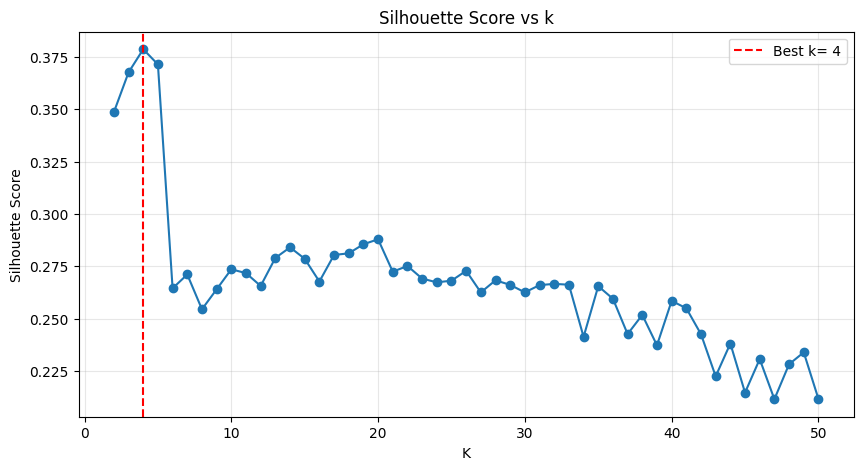

In [10]:
plt.rcdefaults()
X_full_df = full_df.drop(columns=["Family", "Genus", "Species"])
y_full_df = full_df[["Family", "Genus", "Species"]]

def get_opt_k(X_data, rand_state):
    k_range = range(2, 51)
    silhouette_scores = {}
    for k in k_range:
        kmeans = KMeans(n_clusters=k,  n_init=10, max_iter=500, random_state=rand_state)
        cluster_fit = kmeans.fit_predict(X_data)
        silhouette_scores[k] = silhouette_score(X_data, cluster_fit)

    k_opt = max(silhouette_scores, key=silhouette_scores.get)
    k_opt_score = silhouette_scores[k_opt]
    k_scores_df = pd.DataFrame(list(silhouette_scores.items()), columns=['k', 'silhouette_score'])

    return k_opt, k_opt_score, k_scores_df

k_opt, k_opt_score, k_scores_df = get_opt_k(X_full_df, 42)

print(f"Optimal k = {k_opt} with Silhouette Score = {k_opt_score:.4f}")
k_scores_sort_df = k_scores_df.sort_values('silhouette_score', ascending=False)
display(k_scores_sort_df.round(4).style.hide(axis='index'))

k_scores_sort_df = k_scores_df.sort_values('silhouette_score')
plt.figure(figsize=(10, 5))
plt.plot(k_scores_df['k'], k_scores_df['silhouette_score'], marker='o', linestyle='-')
plt.axvline(x=k_opt, color='r', linestyle='--', label=f'Best k= {k_opt}')
plt.xlabel('K')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs k')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### (b) In each cluster, for each label (family, genus and species) determine which is the majority by reading the true labels.


In [11]:
def get_major_cluster(k_opt, X_data, y_data, rand_state):
    kmeans_opt = KMeans(n_clusters=k_opt, n_init=10, max_iter=500, random_state=rand_state)
    clusters = kmeans_opt.fit_predict(X_data)
    clustered_df = y_data.copy()
    clustered_df['Cluster'] = clusters

    majority_labels = {}
    for cluster in range(k_opt):
        cluster_data = clustered_df[clustered_df['Cluster'] == cluster]
        maj_family = cluster_data['Family'].value_counts().index[0]
        maj_genus = cluster_data['Genus'].value_counts().index[0]
        maj_species = cluster_data['Species'].value_counts().index[0]

        majority_labels[cluster] = {"Family": maj_family, "Genus": maj_genus, "Species": maj_species}

    majority_df = pd.DataFrame(majority_labels).T
    majority_df.index.name = 'Cluster'

    return majority_df, clusters

majority_df, clusters_k_opt = get_major_cluster(k_opt, X_full_df, y_full_df, 42)
print(f"Majority Labels per Cluster with k = {k_opt}")
display(majority_df.rename(index=lambda x: x + 1))

Majority Labels per Cluster with k = 4


,Family,Genus,Species
Cluster,,,
1,Leptodactylidae,Adenomera,AdenomeraHylaedactylus
2,Hylidae,Hypsiboas,HypsiboasCinerascens
3,Dendrobatidae,Ameerega,Ameeregatrivittata
4,Hylidae,Hypsiboas,HypsiboasCordobae


### (c) Calculate the average Hamming distance, Hamming score, and Hamming loss

In [12]:
def get_hamming(y_data, cluster_opt, majority_df):
    y_pred = pd.DataFrame(index=y_data.index, columns=y_data.columns)

    for cluster_n in majority_df.index:
        indices = np.where(cluster_opt == cluster_n)[0]
        y_pred.iloc[indices] = majority_df.loc[cluster_n].values

    h_loss = (y_data.values != y_pred.values).mean()
    h_score = 1 - h_loss
    h_dist = h_loss * y_data.shape[1]

    return h_dist, h_score, h_loss

h_dist, h_score, h_loss = get_hamming(y_full_df, clusters_k_opt, majority_df)

print(f"K-Means Clustering Results for k={k_opt}")
print(f"Average Hamming Distance =  {h_dist:.4f}")
print(f"Hamming Score =  {h_score:.4f}")
print(f"Hamming Loss = {h_loss:.4f}")

K-Means Clustering Results for k=4
Average Hamming Distance =  0.6673
Hamming Score =  0.7776
Hamming Loss = 0.2224


### Monte Carlo Simulation

In [13]:
np.random.seed(42)
mc_rand_states = np.random.randint(0, 100000, size=50)
mc_results = {}

for r in range(50):
    current_seed = mc_rand_states[r]
    majority_df_run, clusters_run = get_major_cluster(k_opt, X_full_df, y_full_df, rand_state=current_seed)
    h_dist_run, h_score_run, h_loss_run = get_hamming(y_full_df, clusters_run, majority_df_run)

    mc_results[r + 1] = { "h_dist": h_dist_run,"h_score": h_score_run, "h_loss": h_loss_run,"majority_df": majority_df_run}

hamming_distances = [mc_results[r]["h_dist"] for r in mc_results]
hamming_scores = [mc_results[r]["h_score"] for r in mc_results]
hamming_losses = [mc_results[r]["h_loss"] for r in mc_results]

print(f"Monte Carlo Results (50 runs with k={k_opt})")
print(f"Avg Hamming Distance: {np.mean(hamming_distances):.4f} (Std: {np.std(hamming_distances):.4f})")
print(f"Avg Hamming Score: {np.mean(hamming_scores):.4f} (Std: {np.std(hamming_scores):.4f})")
print(f"Avg Hamming Loss: {np.mean(hamming_losses):.4f} (Std: {np.std(hamming_losses):.4f})")


Monte Carlo Results (50 runs with k=4)
Avg Hamming Distance: 0.6698 (Std: 0.0115)
Avg Hamming Score: 0.7767 (Std: 0.0038)
Avg Hamming Loss: 0.2233 (Std: 0.0038)


### References:
- https://scikit-learn.org/stable/modules/model_evaluation.html#hamming-loss
- https://scikit-learn.org/stable/modules/generated/sklearn.metrics.hamming_loss.html
- https://scikit-learn.org/stable/modules/svm.html
- https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html
- https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVC.html#sklearn.svm.LinearSVC
- https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTE.html
- https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html
- https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html